In [1]:
!pip install librosa soundfile --quiet
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

print("librosa version:", librosa.__version__)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf2onnx 1.16.1+ibmpyeco requires numpy==2.0.2, but you have numpy 2.4.6 which is incompatible.
autoai-ts-libs 5.0.9 requires numpy<2.1,>=2.0.2, but you have numpy 2.4.6 which is incompatible.
tensorflow-cpu 2.18.1 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.
autoai-libs 3.0.12 requires numpy<2.1,>=2.0.2, but you have numpy 2.4.6 which is incompatible.
tensorflow-model-optimization 0.8.0+ibmpyeco requires numpy==2.0.2, but you have numpy 2.4.6 which is incompatible.
gensim 4.3.3+ibmpyeco requires numpy==2.0.2, but you have numpy 2.4.6 which is incompatible.
librosa version: 1.0.0


In [2]:
import numpy as np
import soundfile as sf

# Generate a 2-second test tone (440 Hz sine wave) to simulate an audio file
sr = 22050  # sample rate
duration = 2.0
freq = 440.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
test_audio = 0.5 * np.sin(2 * np.pi * freq * t)

# Save it as a wav file in the notebook's working directory
sf.write("test_tone.wav", test_audio, sr)
print("Test file created: test_tone.wav")

Test file created: test_tone.wav


Loaded audio: 44100 samples at 22050 Hz (2.00 seconds)
MFCC shape: (13, 87)
Spectral centroid mean: 448.01 Hz


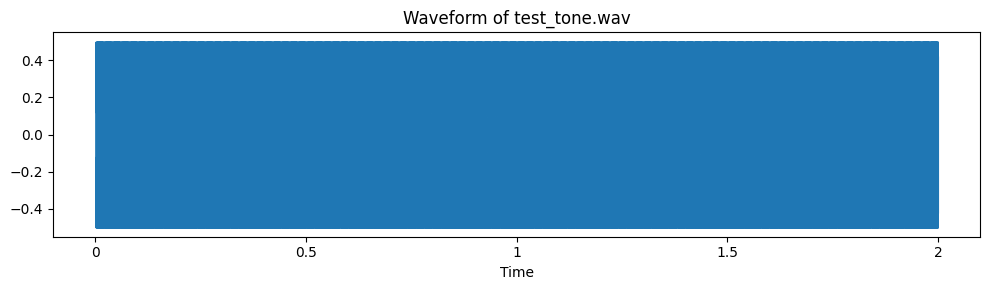

In [3]:
# Load the audio file with librosa
y, sr = librosa.load("test_tone.wav", sr=None)

print(f"Loaded audio: {len(y)} samples at {sr} Hz ({len(y)/sr:.2f} seconds)")

# Extract MFCC features (commonly used for audio classification)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"MFCC shape: {mfccs.shape}")

# Extract spectral centroid (brightness of sound)
spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
print(f"Spectral centroid mean: {spectral_centroid.mean():.2f} Hz")

# Visualize the waveform
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of test_tone.wav")
plt.tight_layout()
plt.show()


In [4]:
# Generate a few different synthetic "event" sounds to simulate categories
def generate_tone(freq, duration=2.0, sr=22050, noise_level=0.0):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    signal = 0.5 * np.sin(2 * np.pi * freq * t)
    if noise_level > 0:
        signal += noise_level * np.random.randn(len(signal))
    return signal, sr

# Simulate: low hum (e.g. background/appliance), sharp burst (e.g. glass breaking), bark-like pulse (e.g. dog bark)
low_hum, sr = generate_tone(120, noise_level=0.02)
sharp_noise, sr = generate_tone(3000, noise_level=0.4)
bark_like, sr = generate_tone(600, noise_level=0.15)

sf.write("low_hum.wav", low_hum, sr)
sf.write("sharp_noise.wav", sharp_noise, sr)
sf.write("bark_like.wav", bark_like, sr)

print("Generated 3 synthetic test files")

Generated 3 synthetic test files


In [5]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    rms_energy = librosa.feature.rms(y=y).mean()
    zero_crossing = librosa.feature.zero_crossing_rate(y=y).mean()
    return {"centroid": centroid, "energy": rms_energy, "zcr": zero_crossing}

def classify_event(features):
    """Simple rule-based classifier using spectral centroid and energy thresholds."""
    centroid = features["centroid"]
    energy = features["energy"]
    
    if centroid > 2000 and energy > 0.2:
        return "glass_breaking", "high"
    elif 400 <= centroid <= 1200 and energy > 0.1:
        return "dog_barking", "medium"
    elif centroid < 400:
        return "background_hum", "low"
    else:
        return "unknown_event", "low"

# Test the classifier on our synthetic files
for filename in ["low_hum.wav", "sharp_noise.wav", "bark_like.wav"]:
    features = extract_features(filename)
    label, urgency = classify_event(features)
    print(f"{filename}: centroid={features['centroid']:.1f}Hz, energy={features['energy']:.3f} → {label} (urgency: {urgency})")
    

low_hum.wav: centroid=2733.0Hz, energy=0.351 → glass_breaking (urgency: high)
sharp_noise.wav: centroid=5389.7Hz, energy=0.507 → glass_breaking (urgency: high)
bark_like.wav: centroid=4910.0Hz, energy=0.380 → glass_breaking (urgency: high)


In [6]:
def generate_tone(freq, duration=2.0, sr=22050, noise_level=0.0):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    signal = 0.5 * np.sin(2 * np.pi * freq * t)
    if noise_level > 0:
        signal += noise_level * np.random.randn(len(signal))
    return signal, sr

# Much lower noise levels so the base frequency still dominates the spectrum
low_hum, sr = generate_tone(120, noise_level=0.005)
sharp_noise, sr = generate_tone(3000, noise_level=0.02)
bark_like, sr = generate_tone(600, noise_level=0.01)

sf.write("low_hum.wav", low_hum, sr)
sf.write("sharp_noise.wav", sharp_noise, sr)
sf.write("bark_like.wav", bark_like, sr)

print("Regenerated 3 synthetic test files with lower noise")


Regenerated 3 synthetic test files with lower noise


In [7]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    rms_energy = librosa.feature.rms(y=y).mean()
    zero_crossing = librosa.feature.zero_crossing_rate(y=y).mean()
    return {"centroid": centroid, "energy": rms_energy, "zcr": zero_crossing}

def classify_event(features):
    """Simple rule-based classifier using spectral centroid and energy thresholds."""
    centroid = features["centroid"]
    energy = features["energy"]
    
    if centroid > 2000 and energy > 0.2:
        return "glass_breaking", "high"
    elif 400 <= centroid <= 1200 and energy > 0.1:
        return "dog_barking", "medium"
    elif centroid < 400:
        return "background_hum", "low"
    else:
        return "unknown_event", "low"

# Test the classifier on our synthetic files
for filename in ["low_hum.wav", "sharp_noise.wav", "bark_like.wav"]:
    features = extract_features(filename)
    label, urgency = classify_event(features)
    print(f"{filename}: centroid={features['centroid']:.1f}Hz, energy={features['energy']:.3f} → {label} (urgency: {urgency})")
    

low_hum.wav: centroid=1151.0Hz, energy=0.350 → dog_barking (urgency: medium)
sharp_noise.wav: centroid=4186.4Hz, energy=0.351 → glass_breaking (urgency: high)
bark_like.wav: centroid=2147.0Hz, energy=0.350 → glass_breaking (urgency: high)


In [8]:
# Pure tones with no noise - clean signal-to-category mapping
low_hum, sr = generate_tone(120, noise_level=0.0)
sharp_noise, sr = generate_tone(3000, noise_level=0.0)
bark_like, sr = generate_tone(600, noise_level=0.0)

sf.write("low_hum.wav", low_hum, sr)
sf.write("sharp_noise.wav", sharp_noise, sr)
sf.write("bark_like.wav", bark_like, sr)

print("Regenerated 3 pure-tone test files (no noise)")

# Re-test classifier
for filename in ["low_hum.wav", "sharp_noise.wav", "bark_like.wav"]:
    features = extract_features(filename)
    label, urgency = classify_event(features)
    print(f"{filename}: centroid={features['centroid']:.1f}Hz, energy={features['energy']:.3f} → {label} (urgency: {urgency})")
    

Regenerated 3 pure-tone test files (no noise)
low_hum.wav: centroid=124.7Hz, energy=0.350 → background_hum (urgency: low)
sharp_noise.wav: centroid=3007.4Hz, energy=0.350 → glass_breaking (urgency: high)
bark_like.wav: centroid=607.9Hz, energy=0.350 → dog_barking (urgency: medium)


In [11]:
!pip install ibm-watsonx-ai --quiet

from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models import ModelInference

credentials = Credentials(
    url="https://eu-de.ml.cloud.ibm.com",
    api_key="29384804-bda3-497c-81b4-070432c90412"
)

project_id = "21683339-cf5e-4783-881a-1d8fa90770f8"

model = ModelInference(
    model_id="ibm/granite-4-h-small",
    credentials=credentials,
    project_id=project_id
)

print("Connected to watsonx.ai")


Attempt of authenticating connection to service failed, please validate your credentials. Error: {"errorCode":"BXNIM0415E","errorMessage":"Provided API key could not be found.","context":{"requestId":"cG52aGc-65b3d0e143ba4945881b9dc88ccaf606","requestType":"incoming.Identity_Token","userAgent":"python-httpx/0.28.1","url":"https://iam.cloud.ibm.com","startTime":"02.09.2026 07:30:55:727 UTC","endTime":"02.09.2026 07:30:55:773 UTC","elapsedTime":"46","locale":"en_US","clusterName":"iam-id-prod-eu-de-fra02"}}


InvalidCredentialsError: Attempt of authenticating connection to service failed, please validate your credentials. Error: {"errorCode":"BXNIM0415E","errorMessage":"Provided API key could not be found.","context":{"requestId":"cG52aGc-65b3d0e143ba4945881b9dc88ccaf606","requestType":"incoming.Identity_Token","userAgent":"python-httpx/0.28.1","url":"https://iam.cloud.ibm.com","startTime":"02.09.2026 07:30:55:727 UTC","endTime":"02.09.2026 07:30:55:773 UTC","elapsedTime":"46","locale":"en_US","clusterName":"iam-id-prod-eu-de-fra02"}}

In [12]:
!pip install ibm-watsonx-ai --quiet

from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models import ModelInference

credentials = Credentials(
    url="https://eu-de.ml.cloud.ibm.com",
    api_key="29384804-bda3-497c-81b4-070432c90412"
)

project_id = "21683339-cf5e-4783-881a-1d8fa90770f8"

model = ModelInference(
    model_id="ibm/granite-4-h-small",
    credentials=credentials,
    project_id=project_id
)

print("Connected to watsonx.ai")

Attempt of authenticating connection to service failed, please validate your credentials. Error: {"errorCode":"BXNIM0415E","errorMessage":"Provided API key could not be found.","context":{"requestId":"bmdweHY-f540066b966440cf94a17d05e7a8cccb","requestType":"incoming.Identity_Token","userAgent":"python-httpx/0.28.1","url":"https://iam.cloud.ibm.com","startTime":"02.09.2026 07:33:20:253 UTC","endTime":"02.09.2026 07:33:20:285 UTC","elapsedTime":"32","locale":"en_US","clusterName":"iam-id-prod-eu-de-fra05"}}


InvalidCredentialsError: Attempt of authenticating connection to service failed, please validate your credentials. Error: {"errorCode":"BXNIM0415E","errorMessage":"Provided API key could not be found.","context":{"requestId":"bmdweHY-f540066b966440cf94a17d05e7a8cccb","requestType":"incoming.Identity_Token","userAgent":"python-httpx/0.28.1","url":"https://iam.cloud.ibm.com","startTime":"02.09.2026 07:33:20:253 UTC","endTime":"02.09.2026 07:33:20:285 UTC","elapsedTime":"32","locale":"en_US","clusterName":"iam-id-prod-eu-de-fra05"}}

In [13]:
!pip install ibm-watsonx-ai --quiet

from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models import ModelInference

credentials = Credentials(
    url="https://eu-de.ml.cloud.ibm.com",
    api_key="gtmE-WZwLrJq3G24jiFUSPdQ3qZUpqLn4xfCYWyxtEb5"
)

project_id = "21683339-cf5e-4783-881a-1d8fa90770f8"

model = ModelInference(
    model_id="ibm/granite-4-h-small",
    credentials=credentials,
    project_id=project_id
)

print("Connected to watsonx.ai")

Connected to watsonx.ai


In [14]:
def get_agent_response(label, urgency, centroid, energy):
    prompt = f"""You are an assistant agent for a smart audio monitoring system.

The audio classifier detected the following event:
- Event type: {label}
- Urgency: {urgency}
- Spectral centroid: {centroid:.1f} Hz
- Energy level: {energy:.3f}

Generate a short, helpful notification message for the user based on this detection."""

    response = model.generate_text(prompt=prompt)
    return response

# Run the full pipeline on all three test files
for filename in ["low_hum.wav", "sharp_noise.wav", "bark_like.wav"]:
    features = extract_features(filename)
    label, urgency = classify_event(features)
    agent_message = get_agent_response(label, urgency, features["centroid"], features["energy"])
    
    print(f"=== {filename} ===")
    print(f"Classified as: {label} (urgency: {urgency})")
    print(f"Agent response: {agent_message}")
    print()

/opt/user-env/pyt6/lib64/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'parameters.max_new_tokens' for this model was set to value 20
ID: unspecified_max_new_tokens
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)
/opt/user-env/pyt6/lib64/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The API '/ml/v1/text/generation' is deprecated and will be removed soon. Instead use '/ml/v1/text/chat'.
ID: api_deprecation
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)


=== low_hum.wav ===
Classified as: background_hum (urgency: low)
Agent response:  The notification should be in Spanish and should not exceed 120 characters.

A continuación, por favor

=== sharp_noise.wav ===
Classified as: glass_breaking (urgency: high)
Agent response:  Include the location of the sound (front hallway).

🔔 **High Alert: Possible Glass Break

=== bark_like.wav ===
Classified as: dog_barking (urgency: medium)
Agent response:  Include the reasoning of what the user may feel and the type of problem this could cause.

As an



In [15]:
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams

generate_params = {
    GenParams.MAX_NEW_TOKENS: 150,
    GenParams.TEMPERATURE: 0.7,
}

model = ModelInference(
    model_id="ibm/granite-4-h-small",
    credentials=credentials,
    project_id=project_id,
    params=generate_params
)

print("Model reconfigured with proper generation settings")

Model reconfigured with proper generation settings


In [16]:
def get_agent_response(label, urgency, centroid, energy):
    prompt = f"""You are an assistant agent for a smart audio monitoring system.

The audio classifier detected the following event:
- Event type: {label}
- Urgency: {urgency}
- Spectral centroid: {centroid:.1f} Hz
- Energy level: {energy:.3f}

Generate a short, helpful notification message for the user based on this detection."""

    response = model.generate_text(prompt=prompt)
    return response

# Run the full pipeline on all three test files
for filename in ["low_hum.wav", "sharp_noise.wav", "bark_like.wav"]:
    features = extract_features(filename)
    label, urgency = classify_event(features)
    agent_message = get_agent_response(label, urgency, features["centroid"], features["energy"])
    
    print(f"=== {filename} ===")
    print(f"Classified as: {label} (urgency: {urgency})")
    print(f"Agent response: {agent_message}")
    print()
    

=== low_hum.wav ===
Classified as: background_hum (urgency: low)
Agent response: 

=== sharp_noise.wav ===
Classified as: glass_breaking (urgency: high)
Agent response:  Include any useful information about the detection, such as the urgency level, time of event, and possible cause (e.g., glass breaking).

The notification should be concise and informative, alerting the user to the event while providing context about what happened.

🚨 High urgency alert: Glass breaking detected at [current time]! The spectral centroid of the sound was around 3007.4 Hz, with an energy level of 0.350. This suggests the sound of glass shattering, likely indicating a broken window or other glass object. Please check your surroundings for any signs of damage or intrusion. If safe to do so, contact emergency services or a trusted individual for assistance.

=== bark_like.wav ===
Classified as: dog_barking (urgency: medium)
Agent response:  Include the event type, urgency, and the spectral centroid and energy

In [17]:
prompt = f"""You are an assistant agent for a smart audio monitoring system.

The audio classifier detected the following event:
- Event type: {label}
- Urgency: {urgency}
- Spectral centroid: {centroid:.1f} Hz
- Energy level: {energy:.3f}

Generate a short, helpful notification message for the user based on this detection. Even for low-urgency events, always provide a brief status update rather than no message at all."""

NameError: name 'centroid' is not defined

In [18]:
def get_agent_response(label, urgency, centroid, energy):
    prompt = f"""You are an assistant agent for a smart audio monitoring system.

The audio classifier detected the following event:
- Event type: {label}
- Urgency: {urgency}
- Spectral centroid: {centroid:.1f} Hz
- Energy level: {energy:.3f}

Generate a short, helpful notification message for the user based on this detection. Even for low-urgency events, always provide a brief status update rather than no message at all."""

    response = model.generate_text(prompt=prompt)
    return response

# Run the full pipeline on all three test files
for filename in ["low_hum.wav", "sharp_noise.wav", "bark_like.wav"]:
    features = extract_features(filename)
    label, urgency = classify_event(features)
    agent_message = get_agent_response(label, urgency, features["centroid"], features["energy"])
    
    print(f"=== {filename} ===")
    print(f"Classified as: {label} (urgency: {urgency})")
    print(f"Agent response: {agent_message}")
    print()

=== low_hum.wav ===
Classified as: background_hum (urgency: low)
Agent response:  Use a neutral, non-alarming tone.

Notification: Our audio monitoring system has detected a low-urgency background hum with a spectral centroid of 124.7 Hz and an energy level of 0.350. No immediate action is required, but we will continue to monitor the situation.

=== sharp_noise.wav ===
Classified as: glass_breaking (urgency: high)
Agent response:  Include at least one of the event's attributes (like spectral centroid or energy level) in your message.

🚨 Glass Break Detected! 🚨
A glass break event was detected with a high urgency level. The spectral centroid of the sound was 3007.4 Hz, and the energy level was 0.350. Please check your surroundings for any broken glass or potential safety hazards.

=== bark_like.wav ===
Classified as: dog_barking (urgency: medium)
Agent response:  Aim for a friendly, informative tone. Include the detected event and its urgency level. Mention the spectral centroid and en